# 01 — Train Per-Channel Noise Models

Trains one Noise2Void + Gaussian Mixture noise model per channel.

**Run `00_datasets.ipynb` first.**  Run `02_train.ipynb` next.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, '../../../src')
from microsplit_reproducibility.workflows.noise_model import train_noise_model_for_channel

DEMO_DIR    = Path('./cpg0016_demo')
DATASET_DIR = DEMO_DIR / 'dataset'
NM_DIR      = DATASET_DIR / 'noise_models'
CHANNELS    = ['DNA', 'RNA', 'ER', 'AGP', 'Mito']

if not DATASET_DIR.exists():
    raise FileNotFoundError(f'{DATASET_DIR} not found — run 00_datasets.ipynb first.')

NM_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
for channel in CHANNELS:
    nm_path = NM_DIR / f'noise_model_{channel}.npz'
    if nm_path.exists():
        print(f'[{channel}] already trained, skipping')
        continue
    print(f'Training: {channel}')
    train_noise_model_for_channel(
        channel=channel,
        dataset_dir=str(DATASET_DIR),
        output_dir=str(NM_DIR),
        n2v_epochs=5,
        nm_epochs=50,
    )

Training: DNA

Processing channel: DNA
[1/6] Loading data...
  Shape: (9, 1080, 1080, 1), dtype: uint16
  Signal range: [222.0, 65535.0]
[2/6] Creating N2V configuration...
[3/6] Training N2V model...


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA A40-24Q') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


...

Predicting: |          | 0/? [00:00<?, ?it/s]

  9 prediction batches
[5/6] Post-processing...
  Signal    shape=(9, 1080, 1080) mean=2306.6 std=1414.9
  Prediction shape=(9, 1080, 1080) mean=2311.8 std=1472.0


[6/6] Fitting GaussianMixture noise model...
[GaussianMixtureNoiseModel] min_sigma: 200.0


0 7.5148396492004395



The trained parameters (noise_model_Mito) is saved at location: cpg0016_demo/dataset/noise_models
  Saved: cpg0016_demo/dataset/noise_models/noise_model_Mito.npz



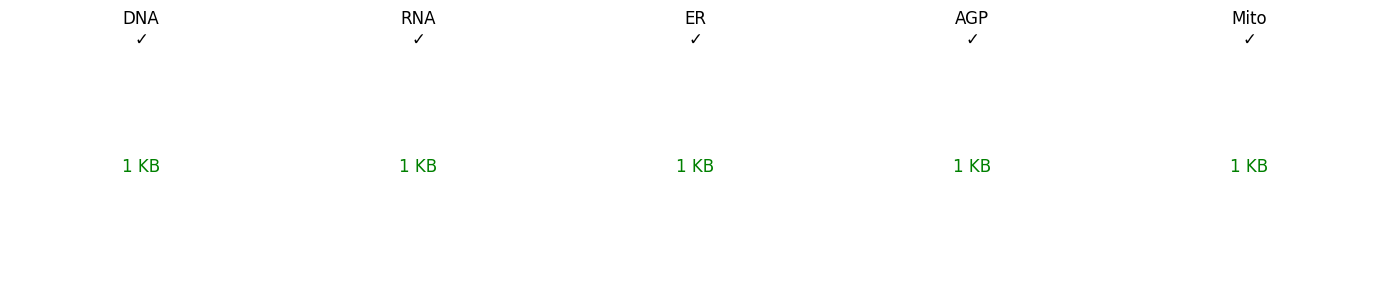

In [3]:
fig, axes = plt.subplots(1, len(CHANNELS), figsize=(14, 3))
for ax, ch in zip(axes, CHANNELS):
    nm_path = NM_DIR / f'noise_model_{ch}.npz'
    ok = nm_path.exists()
    ax.set_title(f'{ch}\n{"✓" if ok else "missing"}')
    ax.text(0.5, 0.5, f'{nm_path.stat().st_size // 1024} KB' if ok else '✗',
            ha='center', va='center', fontsize=12,
            color='green' if ok else 'red', transform=ax.transAxes)
    ax.axis('off')
plt.tight_layout()
plt.show()